In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as cp
from scipy.interpolate import griddata
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from FallbackGen import FallbackGen
from TDECalculator import TDECalculator

plt.style.use("plot_style.mplstyle")
plt.rc('text', usetex=True)

In [2]:
MBH = 1e6
Rp = 18
a = 0.0
N = 1000
E = 1.0
Q = 0.0
orbit="rel"

mass1 = TDECalculator('MAMS1Msun', orbit, MBH, Rp, a)

rtde = mass1.R_TDE
Lz = mass1.mom_kerr_analytic(Rp, a)

In [3]:
sample1 = mass1.rel_whole_star_sample()

In [4]:
radii = sample1['rr']

radii = np.where(
    radii <= 0.5,
    rtde - radii * mass1.Rstar,
    rtde + radii * mass1.Rstar
)

In [5]:
# i = 3
# dE = sample1['dEnergy_random'][i][i]
# dLz = mass1.dLz_random[i][i]
# dQ = mass1.dQ_random[i][i]
# r = radii[i]

In [6]:
dE = dLz = dQ = 0
r = rtde
a = 0
mass_ratio = mass1.mass_ratio

In [7]:
dT = FallbackGen(mass_ratio, a, r, Rp, E, Lz, Q, dE, dLz, dQ, N)

/Users/wanglm/Desktop/USRP 2025/PerTDE/FallbackGen.py:54: RuntimeWarning: invalid value encountered in sqrt
  dr_dτ = self.radial_sign * np.sqrt((E * (r**2 + a**2) - a * Lz)**2 - delta * (r**2 + (Lz - a * E)**2 + q)) / sigma


In [17]:
testt = np.linspace(-100, 200, 4000)

In [18]:
testr = dT.bound_R(testt)
testtime = dT.bound_obs_t(testt)

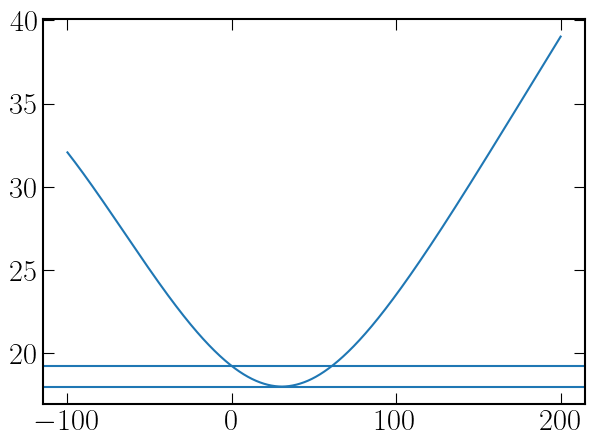

In [19]:
plt.plot(testt, testr)
plt.axhline(18)
plt.axhline(rtde)

In [12]:
dT.bound_R(50000)

array(920772.09252193)

In [13]:
print(dT)